# NY Vir Newtonian N-Body Modeling
Demonstrates Newtonian N-body modeling using Rebound.

In [14]:
%load_ext autoreload
%autoreload 2
import os

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [15]:
from ocpy.data import Data

data = Data.from_file("../ny_vir_minima.xlsx")
data = data.fill_errors(0.0001).calculate_weights()

t0 = 2453174.442769
period = 0.1010159690

oc = data.calculate_oc(
    reference_minimum=t0,
    reference_period=period,
    model_type="pymc"
)

In [16]:
from ocpy.newtonian import NewtonianModel
from ocpy.oc import Parameter

nbody = NewtonianModel(
    central_mass=Parameter(value=0.611, fixed=True),
    T0_ref=t0,
    P_ref=period,
    bodies = [
        {
            "m":     Parameter(value=0.0021, fixed=False, std=1,  min=0),
            "P":     Parameter(value=3170.0, fixed=False, std=1000, min=0), 
            "e":     Parameter(value=0.05,   fixed=False, std=1,  min=0, max=.8),
            "omega": Parameter(value=269.0,  fixed=False, std=200, min=0, max=360),
            "T":     Parameter(value=2443302.0, fixed=False, std=3170.0), 
        },
        {
            "m":     Parameter(value=0.0038, fixed=False, std=1,  min=0),
            "P":     Parameter(value=8260.0, fixed=False, std=1000, min=0), 
            "e":     Parameter(value=0.02,   fixed=False, std=1,  min=0, max=.8),
            "omega": Parameter(value=140.0,  fixed=False, std=200, min=0, max=360),
            "T":     Parameter(value=2421163.0, fixed=False, std=8260.0), 
        }
    ],
    name="nbody"
)
models = [nbody]

In [ ]:
from pymc import DEMetropolisZ
res = oc.fit(models, tune=2000, draws=2000, chains=4)
oc.plot(res)

[autoreload of cutils_ext failed: Traceback (most recent call last):
  File "c:\Users\bar1s\miniconda3\envs\ocpy\Lib\site-packages\IPython\extensions\autoreload.py", line 325, in check
    superreload(m, reload, self.old_objects)
  File "c:\Users\bar1s\miniconda3\envs\ocpy\Lib\site-packages\IPython\extensions\autoreload.py", line 580, in superreload
    module = reload(module)
             ^^^^^^^^^^^^^^
  File "c:\Users\bar1s\miniconda3\envs\ocpy\Lib\importlib\__init__.py", line 168, in reload
    raise ModuleNotFoundError(f"spec not found for the module {name!r}", name=name)
ModuleNotFoundError: spec not found for the module 'cutils_ext'
]


Inference data with groups:
	> posterior
	> sample_stats
	> observed_data

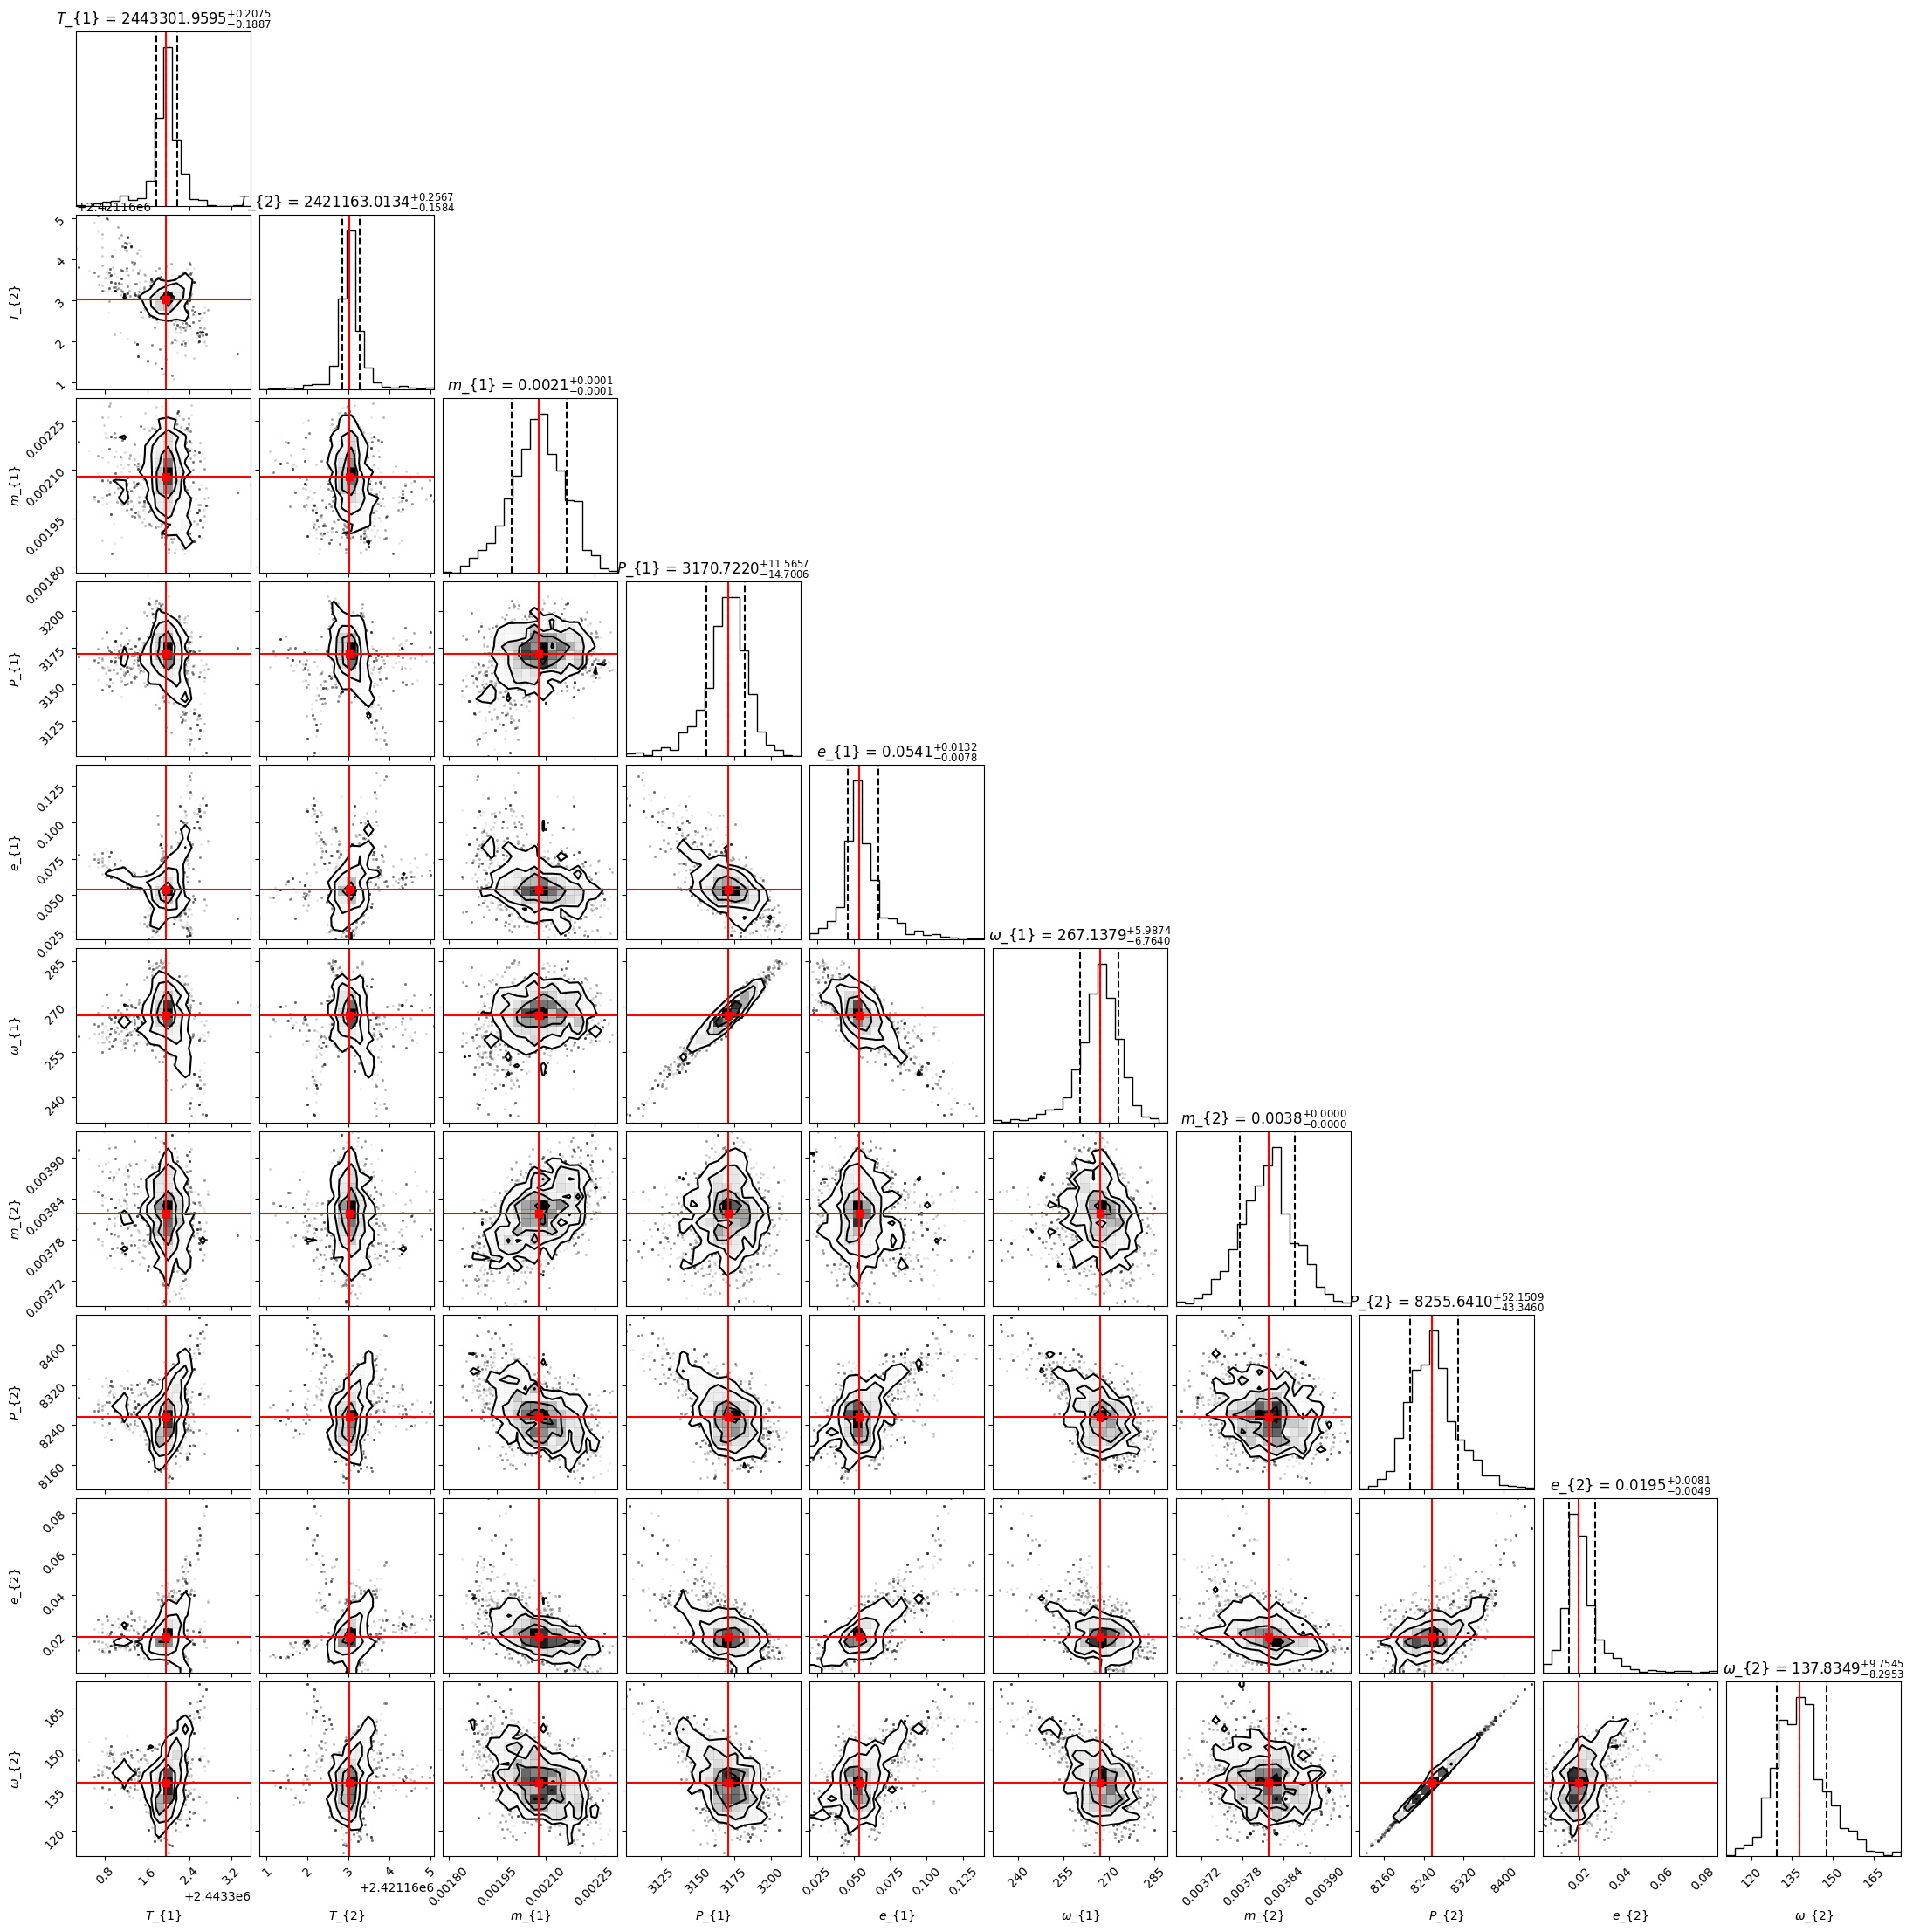

In [18]:
oc.corner(res)
res

In [19]:
cleaned_res = oc.clean(res)

Inference data with groups:
	> posterior
	> sample_stats
	> observed_data

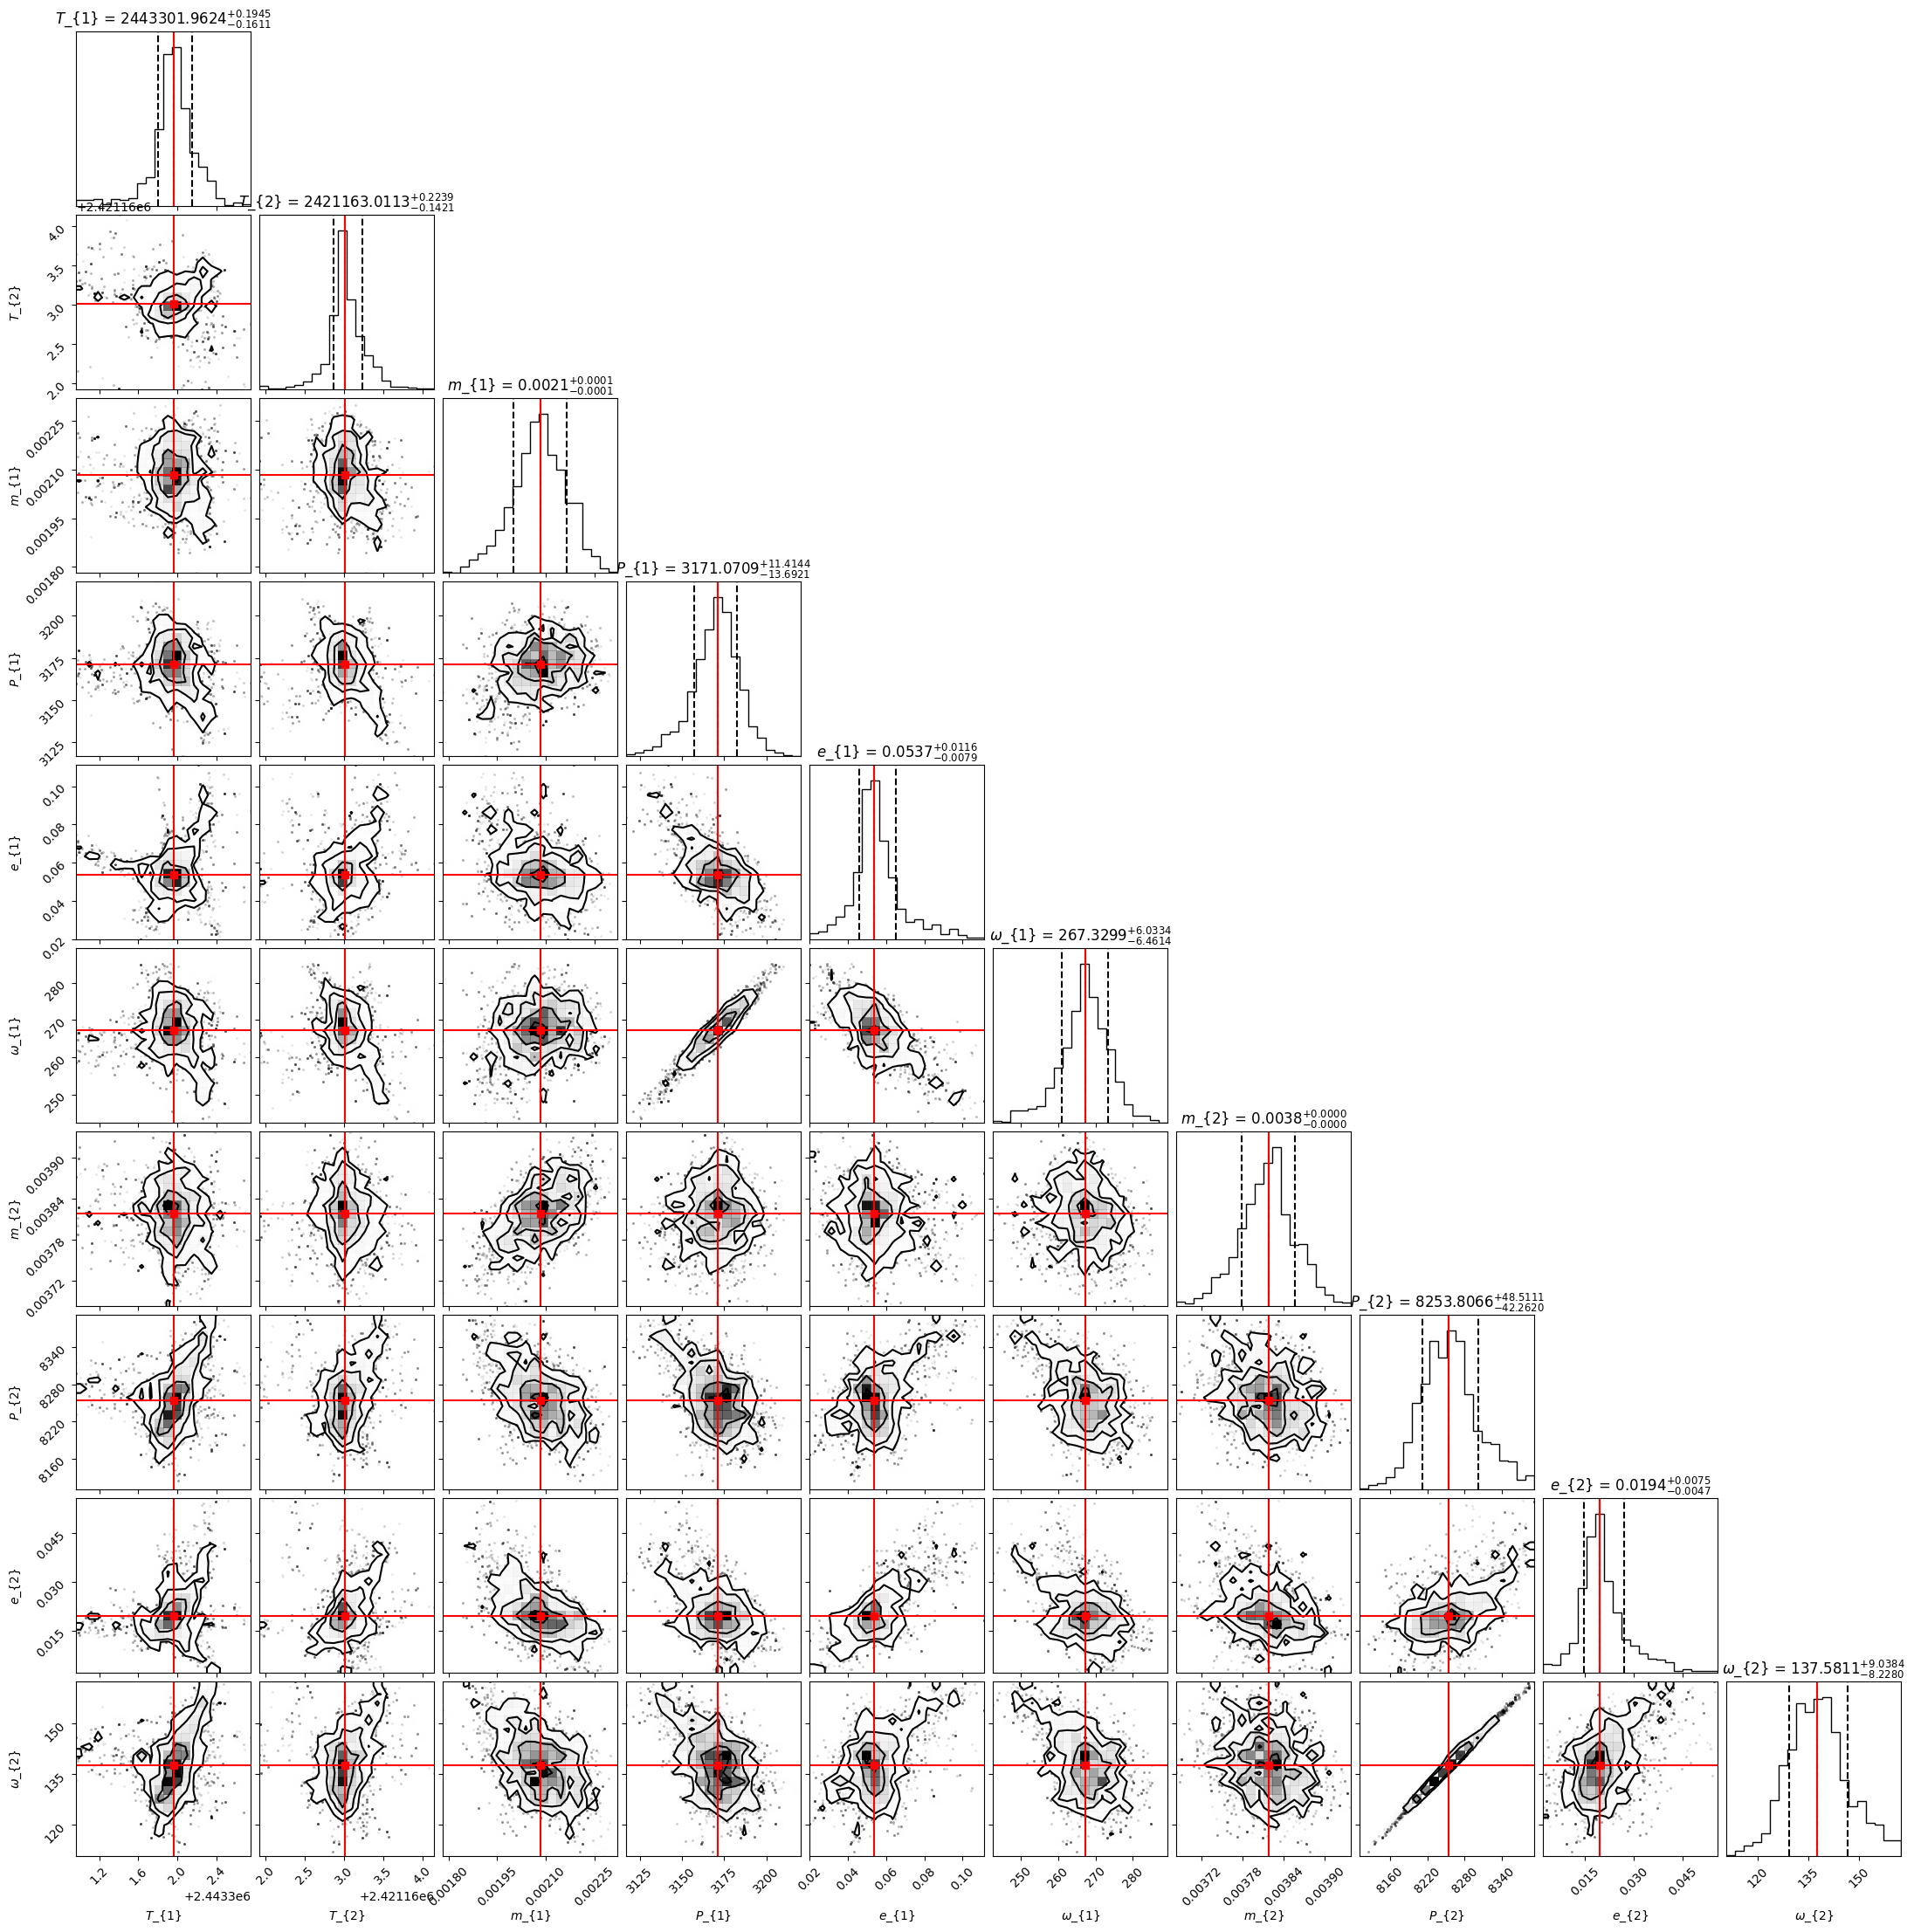

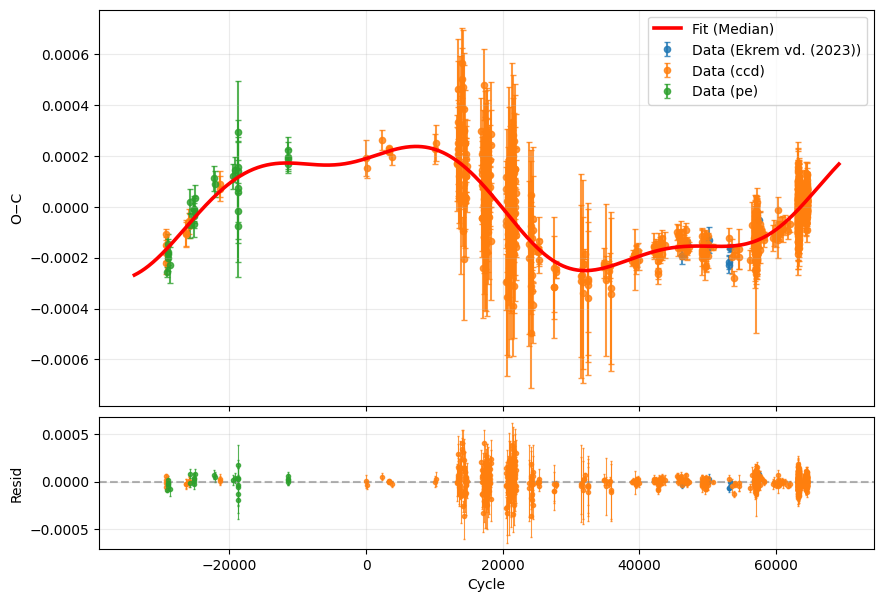

In [20]:
oc.corner(cleaned_res)
oc.plot(cleaned_res, extension_factor=0.05, model_components=models)
res